**Human in the Loop MiddleWare**

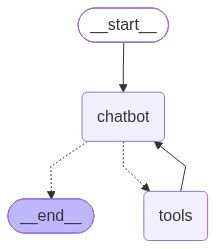

In [24]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START ,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode , tools_condition
from langgraph.types import Command,interrupt

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()


from langchain_groq import ChatGroq
llm = ChatGroq(
    model="openai/gpt-oss-20b"
)



class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """request assistance from a human expert when expert guidance is needed."""
    human_response = interrupt({"query":query})
    return human_response["data"]

tavily_tool = TavilySearch(max_results=2)
tools =[tavily_tool,human_assistance]

llm_with_tools=llm.bind_tools(tools)

def chatbot(state:State):
    # because we will be interuupting during tool execution,
    # we dsiable paralled tool calling to avoid repeating any
    # tool invocation when we resume.
    message=llm_with_tools.invoke(state['messages'])

    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node('tools',tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge(START,'chatbot')
graph_builder.add_edge("tools",'chatbot')

graph= graph_builder.compile(checkpointer=memory)
graph

In [2]:
tool.invoke("what happend for the tesla stock today?")

{'query': 'what happend for the tesla stock today?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.youtube.com/watch?v=PSgMvKkSP7I',
   'title': 'Tesla Stock: WTF Just Happened? Collapses -15% In One Day',
   'content': "Walmart down, Visa down, Mastercard down, Intel down. An absolute bloodbath today. A sea of red. It's red as far as the eye can see. By the time the market wrapped up, many of these were down even further. Is this the end of the world? No. Is it an absolute bloodbath, red as far as the eye can see? Absolutely. Tesla stock ended the day down more than 14 and 1/2. Let's just call it 15%. Now in the low $300 range after shedding more than 50 bucks today. As is usually the case when there tend to [...] bumpy ride between now and then. Started the last 12 months in the low 300s, surged past 450, then almost to 500, then a collapse, then a surge, and another collapse. Miraculously, somehow SpaceX stock dodged the bullet today

In [32]:
# user_input ="I need some expert guidance for building an AI Agent. could you request assistance for me "
user_input ="What be the best approach to start preparing for gate DS AI exam ?? "
config = {"configurable":{"thread_id":"1"}}

responses=graph.stream(
    {
        "messages":user_input#[("user",user_input)]
    },
    config=config,
    stream_mode="values",
)        

In [18]:
responses

<generator object Pregel.stream at 0x00000284B3287470>

In [33]:
for response in responses:
    if "messages" in response:
        response["messages"][-1].pretty_print()

================================ Human Message =================================

What be the best approach to start preparing for gate DS AI exam ?? 
================================== Ai Message ==================================

## 🚀 Quick‑Start Roadmap for the GATE DS AI Exam

| Phase | Duration | Key Focus | Resources & Tips |
|-------|----------|-----------|------------------|
| **1️⃣ Foundation Review** | 4–6 weeks | • Core DS topics (Probability, Statistics, Linear Algebra, Optimization) <br>• Basic ML concepts (regression, classification, clustering, dimensionality reduction) | • *“Introduction to Statistical Learning”* (James et al.) <br>• *“Pattern Recognition and Machine Learning”* (Bishop) <br>• Khan Academy/YouTube playlists for linear algebra & probability |
| **2️⃣ Deep Dive into AI/ML** | 6–8 weeks | • Neural networks & deep learning fundamentals <br>• CNNs, RNNs, Transformers <br>• Reinforcement learning basics | • *“Deep Learning”* (Goodfellow, Bengio, Courville) <b

<!-- Now using command will make it wait for Human Assistance -->

In [34]:
user_input="I need some expert guidance for building an AI Agent. could you request assistance for me "
response = graph.stream({
    "messages":user_input},
    config,
    stream_mode="values"

) 

for resp in response:
    if "messages" in resp:
        resp['messages'][-1].pretty_print()


================================ Human Message =================================

I need some expert guidance for building an AI Agent. could you request assistance for me 
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_489a4c52-dc28-4fb1-80dc-ff3f3afc5a67)
 Call ID: fc_489a4c52-dc28-4fb1-80dc-ff3f3afc5a67
  Args:
    query: I need expert guidance for building an AI Agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_489a4c52-dc28-4fb1-80dc-ff3f3afc5a67)
 Call ID: fc_489a4c52-dc28-4fb1-80dc-ff3f3afc5a67
  Args:
    query: I need expert guidance for building an AI Agent.


In [35]:
Human_response=("we , the experts are here to help! , we do reccomend you check out langraph to build agents"
                "its much more reliable and extensible tha simple automous agents")

Human_command = Command(resume={'data':Human_response})

response=graph.stream(Human_command,
    config,
    stream_mode="values")

for res in response:
    if "messages" in res:
        res['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_489a4c52-dc28-4fb1-80dc-ff3f3afc5a67)
 Call ID: fc_489a4c52-dc28-4fb1-80dc-ff3f3afc5a67
  Args:
    query: I need expert guidance for building an AI Agent.
================================= Tool Message =================================
Name: human_assistance

we , the experts are here to help! , we do reccomend you check out langraph to build agentsits much more reliable and extensible tha simple automous agents
================================== Ai Message ==================================

Sure! Here’s the expert guidance I received:

> **We, the experts, are here to help!**  
> **We highly recommend you check out Langraph to build agents.**  
> It’s much more reliable and extensible than simple autonomous agents.
